# Intro

In [1]:
!pip install mlflow dagshub -q

import numpy as np
import pandas as pd
import os
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    return df

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 68.5 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 85.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import dagshub
dagshub.init(repo_owner='Sula1909', repo_name='ML-Assignment2', mlflow=True)

mlflow.set_tracking_uri("https://dagshub.com/Sula1909/ML-Assignment2.mlflow")

mlflow.set_experiment("RandomForest_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=7e817803-0952-4f1f-8897-46ece99a7a68&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=8f381763e6fd0f658113abf01e774e53ef3a16dd7b557b02b18dc6e53156bda6




Accessing as Sula1909

Initialized MLflow to track repo "Sula1909/ML-Assignment2"

Repository Sula1909/ML-Assignment2 initialized!

<Experiment: artifact_location='mlflow-artifacts:/23f6462058ee49a58b97b95a42c00c9a', creation_time=1777839649180, experiment_id='1', last_update_time=1777839649180, lifecycle_stage='active', name='RandomForest_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [3]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.expand_frame_repr', False)

In [4]:
print("Loading data...")
train_trans = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_id = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

test_trans = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')
test_id = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv')

train = pd.merge(train_trans, train_id, on='TransactionID', how='left')
test = pd.merge(test_trans, test_id, on='TransactionID', how='left')
test.columns = test.columns.str.replace('-', '_')

train = reduce_mem_usage(train)
test = reduce_mem_usage(test)

del train_trans, train_id, test_trans, test_id
print(f"Dataset shape: {train.shape}")
print(f"Dataset shape: {test.shape}")

Loading data...
Dataset shape: (590540, 434)
Dataset shape: (506691, 433)


In [5]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [6]:
test.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,3663549,18403224,31.950001,W,10409,111.0,150.0,visa,226.0,debit,170.0,87.0,1.0,NaN,gmail.com,NaN,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,NaN,NaN,NaN,NaN,418.0,203.0,NaN,NaN,NaN,409.0,T,T,F,NaN,NaN,F,T,T,T,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.000000,W,4272,111.0,1

In [7]:
na_rate = train.isna().mean()
print(na_rate[na_rate > 0.1].sort_values(ascending=False).to_string())

id_24            0.991962
id_25            0.991310
id_07            0.991271
id_08            0.991271
id_21            0.991264
id_26            0.991257
id_22            0.991247
id_23            0.991247
id_27            0.991247
dist2            0.936284
D7               0.934099
id_18            0.923607
D13              0.895093
D14              0.894695
D12              0.890410
id_04            0.887689
id_03            0.887689
D6               0.876068
id_33            0.875895
D9               0.873123
D8               0.873123
id_09            0.873123
id_10            0.873123
id_30            0.868654
id_32            0.868619
id_34            0.868248
id_14            0.864456
V138             0.861237
V141             0.861237
V140             0.861237
V157             0.861237
V149             0.861237
V146             0.861237
V139             0.861237
V142             0.861237
V155             0.861237
V154             0.861237
V153             0.861237
V161        

# EDA & CLEANING

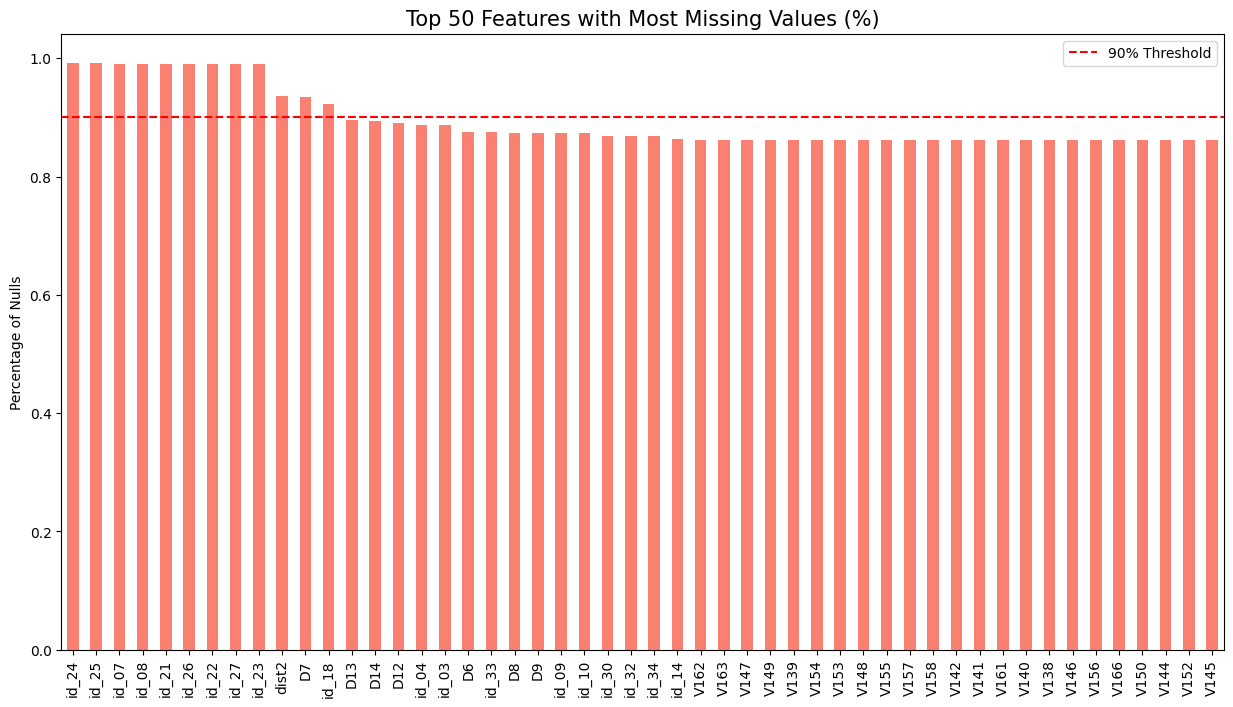

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

null_data = train.isnull().mean().sort_values(ascending=False)[:50]

plt.figure(figsize=(15, 8))
null_data.plot(kind='bar', color='salmon')
plt.title('Top 50 Features with Most Missing Values (%)', fontsize=15)
plt.ylabel('Percentage of Nulls')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.show()

/tmp/ipykernel_57/3930653857.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train['isFraud'], palette='viridis')


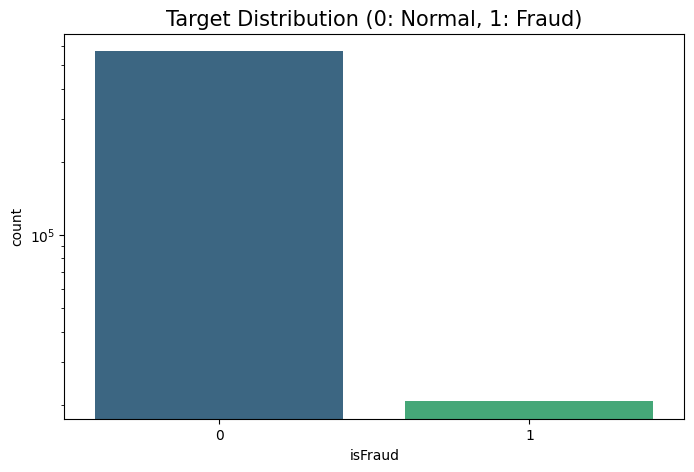

Fraud Percentage: 3.50%


In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x=train['isFraud'], palette='viridis')
plt.title('Target Distribution (0: Normal, 1: Fraud)', fontsize=15)
plt.yscale('log') # Log Scale
plt.show()

print(f"Fraud Percentage: {train['isFraud'].mean()*100:.2f}%")

In [10]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

***> TransactionDT Analysis***

In [11]:
print(train['TransactionDT'].dtype)

print(train["TransactionDT"].isnull().sum())

print(train["TransactionDT"].nunique())

int32
0
573349


In [12]:
train[['TransactionDT']].describe().astype(int)

,TransactionDT
count,590540
mean,7372311
std,4617223
min,86400
25%,3027057
50%,7306527
75%,11246620
max,15811131


/tmp/ipykernel_57/1803339530.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['TransactionDT'],kde = False,bins=60)
/tmp/ipykernel_57/1803339530.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(test['TransactionDT'],kde = False,bins=60)


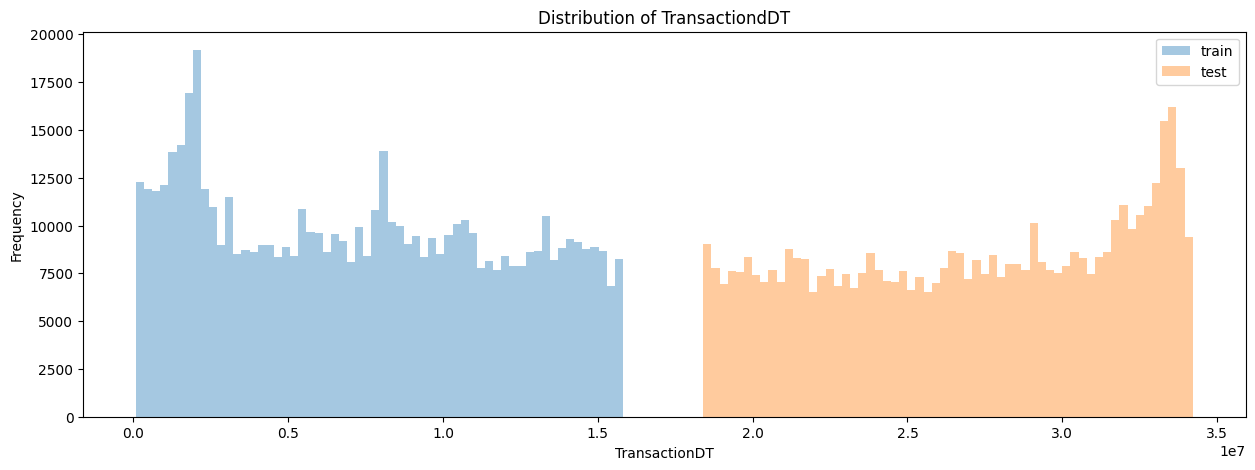

In [13]:
plt.figure(figsize = (15,5))
sns.distplot(train['TransactionDT'],kde = False,bins=60)
sns.distplot(test['TransactionDT'],kde = False,bins=60)
plt.legend(['train', 'test'])
plt.ylabel('Frequency')

plt.title('Distribution of TransactiondDT');
plt.show()

***> TransactionAmt Analysis***

In [14]:
print(train['TransactionAmt'].dtype)

print(train["TransactionAmt"].nunique())

print(train["TransactionAmt"].isnull().sum())
print(test["TransactionAmt"].isnull().sum())

float32
20902
0
0


In [15]:
print(train['TransactionAmt'].describe())
print(" ")
print(test['TransactionAmt'].describe())

count    590540.000000
mean        135.027161
std         239.162689
min           0.251000
25%          43.320999
50%          68.769001
75%         125.000000
max       31937.390625
Name: TransactionAmt, dtype: float64
 
count    506691.000000
mean        134.725571
std         245.790817
min           0.018000
25%          40.000000
50%          67.949997
75%         125.000000
max       10270.000000
Name: TransactionAmt, dtype: float64


In [16]:
train[train.TransactionAmt > 30000]

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
274336,3261336,0,6652360,31937.390625,W,16075,514.0,150.0,mastercard,102.0,credit,205.0,87.0,27.0,NaN,yahoo.com,NaN,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,T,T,T,NaN,NaN,NaN,F,F,T,1.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1422.390015,1422.390015,1422.390015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,1422.390015,1422.390015,1422.390015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
274339,3261339,0,665239

***> ProductCD Analysis***

In [17]:
print(train["ProductCD"].dtype)

print(train["ProductCD"].nunique())

print(train["ProductCD"].isnull().sum())
print(test["ProductCD"].isnull().sum())

object
5
0
0


In [18]:
train["ProductCD"].describe()

count     590540
unique         5
top            W
freq      439670
Name: ProductCD, dtype: object

In [19]:
train["ProductCD"].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

/tmp/ipykernel_57/683254693.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "ProductCD", y = "percentage", data = train_ProductCD, palette = 'pastel')
/tmp/ipykernel_57/683254693.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "ProductCD", y = "percentage", data = test_ProductCD, palette = 'pastel')


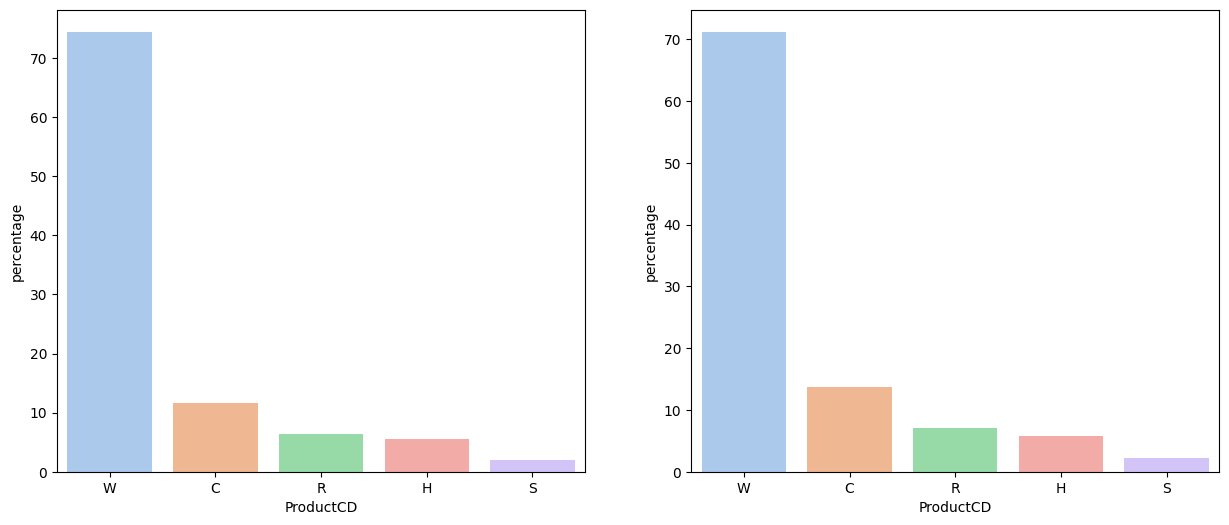

In [20]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
train_ProductCD = train['ProductCD'].value_counts(normalize=True).mul(100).rename('percentage')\
.reset_index()
sns.barplot(x = "ProductCD", y = "percentage", data = train_ProductCD, palette = 'pastel')

plt.subplot(1,2,2)
test_ProductCD = test['ProductCD'].value_counts(normalize=True).mul(100).rename('percentage')\
.reset_index()
sns.barplot(x = "ProductCD", y = "percentage", data = test_ProductCD, palette = 'pastel')

plt.show();

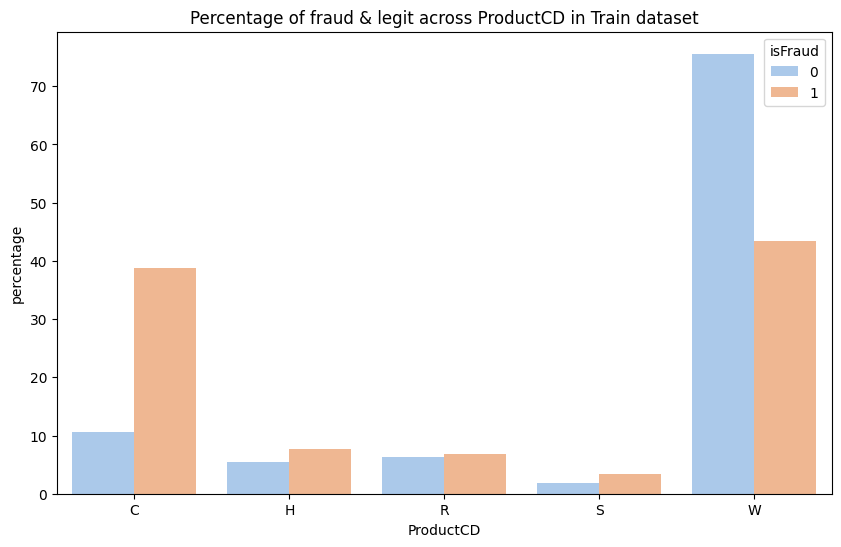

In [21]:
plt.figure(figsize = (10,6))

train_ProductCD = (train.groupby(['isFraud'])['ProductCD'].value_counts(normalize = True).rename('percentage').mul(100).reset_index().sort_values('ProductCD'))

sns.barplot(x = "ProductCD", y = "percentage", hue = "isFraud", data = train_ProductCD, palette = 'pastel')

plt.title('Percentage of fraud & legit across ProductCD in Train dataset')

plt.show();

***> DeviceType & DeviceInfo Analysis***

In [22]:
print(train["DeviceType"].dtype)

print(train['DeviceType'].isnull().sum())

print(train['DeviceType'].unique())

object
449730
[nan 'mobile' 'desktop']


In [23]:
train['DeviceType'].describe()

count      140810
unique          2
top       desktop
freq        85165
Name: DeviceType, dtype: object

In [24]:
train['DeviceType'].value_counts()

DeviceType
desktop    85165
mobile     55645
Name: count, dtype: int64

/tmp/ipykernel_57/3547096603.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x = "DeviceType", y = "percentage", data=test_DeviceType, palette = 'pastel')


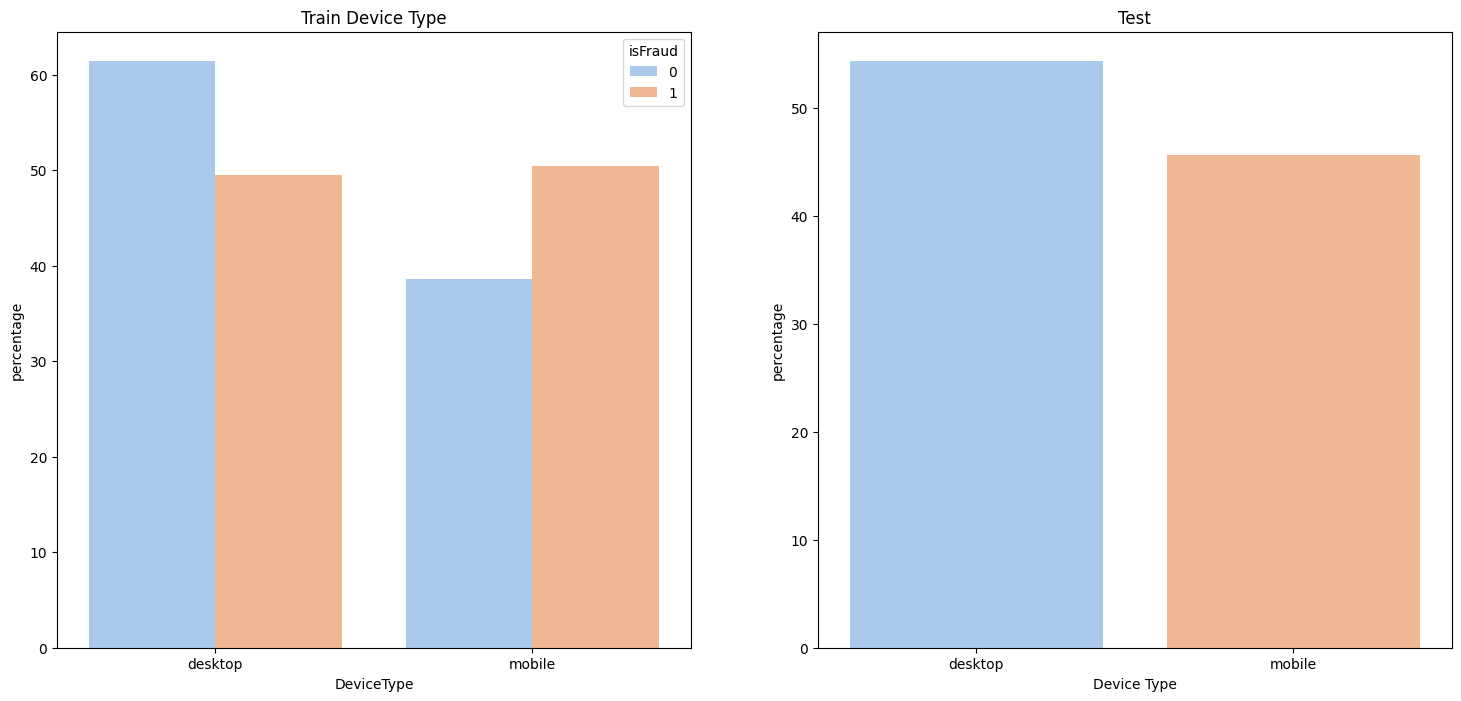

In [25]:
plt.figure(figsize = (18,8))

plt.subplot(1,2,1)

train_DeviceType = (train[~train['DeviceType'].isnull()].groupby(['isFraud'])['DeviceType'].value_counts(normalize=True).rename('percentage').mul(100).reset_index().sort_values('DeviceType'))
sns.barplot(x = "DeviceType", y = "percentage", hue = "isFraud", data = train_DeviceType, palette = 'pastel')
plt.title('Train Device Type')

plt.subplot(1,2,2)

test_DeviceType = test[~test['DeviceType'].isnull()]['DeviceType'].value_counts(normalize = True).mul(100).rename('percentage').reset_index()

sns.barplot( x = "DeviceType", y = "percentage", data=test_DeviceType, palette = 'pastel')
plt.xlabel('Device Type')
plt.title('Test')

plt.show()

In [26]:
print(train["DeviceInfo"].dtype)

print(train['DeviceInfo'].isnull().sum())

print(train['DeviceInfo'].unique())

object
471874
[nan 'SAMSUNG SM-G892A Build/NRD90M' 'iOS Device' ...
 'LDN-LX3 Build/HUAWEILDN-LX3' 'Z955A' 'LG-E975']


In [27]:
train["DeviceInfo"].describe()

count      118666
unique       1786
top       Windows
freq        47722
Name: DeviceInfo, dtype: object

In [28]:
train['DeviceInfo'].value_counts()[:5]

DeviceInfo
Windows        47722
iOS Device     19782
MacOS          12573
Trident/7.0     7440
rv:11.0         1901
Name: count, dtype: int64

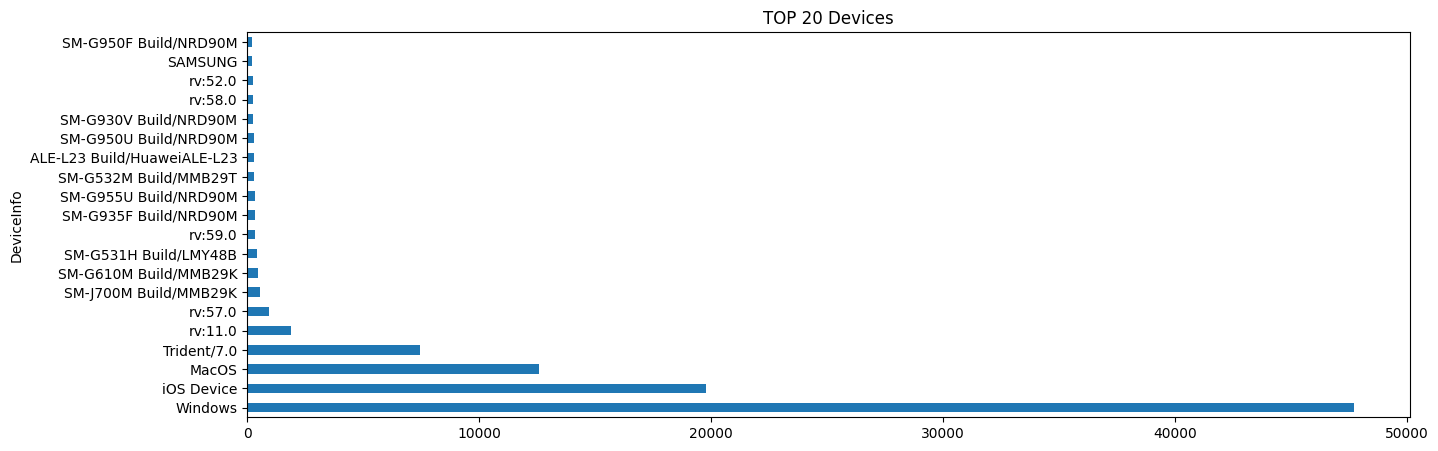

In [29]:
train.groupby('DeviceInfo') \
    .count()['TransactionID'] \
    .sort_values(ascending = False) \
    .head(20) \
    .plot(kind = 'barh', figsize = (15 , 5), title = 'TOP 20 Devices')
    
plt.show()

# Feature Engineering

In [30]:
train['day'] = ((train['TransactionDT'] //(3600*24)-1)%7)+1

test['day'] = ((test['TransactionDT'] //(3600*24)-1)%7)+1

/tmp/ipykernel_57/2737070471.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['day'] = ((train['TransactionDT'] //(3600*24)-1)%7)+1
/tmp/ipykernel_57/2737070471.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['day'] = ((test['TransactionDT'] //(3600*24)-1)%7)+1


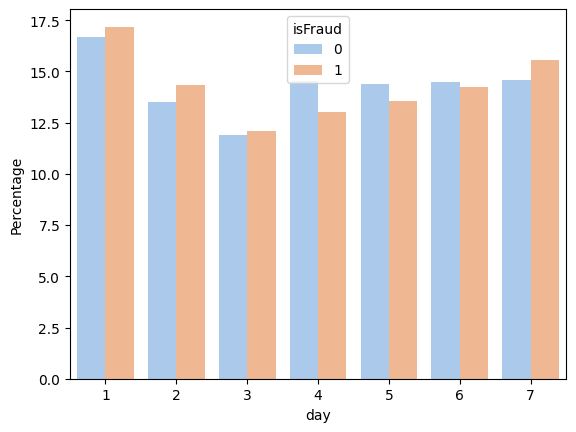

In [31]:
train_days = (train.groupby(['isFraud'])['day']
                     .value_counts(normalize=True)
                     .rename('Percentage')
                     .mul(100)
                     .reset_index()
                     .sort_values('day'))
sns.barplot(x="day", y = "Percentage", hue="isFraud", data = train_days, palette = 'pastel')
plt.show();

In [32]:
train['hour'] = ((train['TransactionDT']//3600)%24)+1

test['hour'] = ((test['TransactionDT']//3600)%24)+1

/tmp/ipykernel_57/1202968795.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['hour'] = ((train['TransactionDT']//3600)%24)+1
/tmp/ipykernel_57/1202968795.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['hour'] = ((test['TransactionDT']//3600)%24)+1


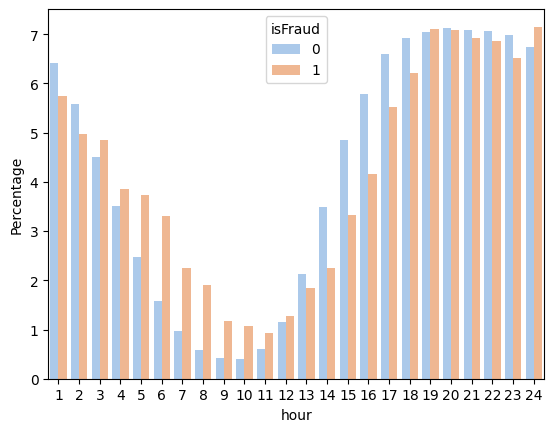

In [33]:
train_hour = (train.groupby(['isFraud'])['hour']
                     .value_counts(normalize = True)
                     .rename('Percentage')
                     .mul(100)
                     .reset_index()
                     .sort_values('hour'))
sns.barplot(x = "hour", y = "Percentage", hue = "isFraud", data = train_hour, palette = 'pastel')
plt.show();

In [34]:
def hourFeature(hour):
    if hour > 4 and hour < 12:
        return "highalert"
    if hour ==12 or hour==19:
        return "lowalert"
    if hour==3 or hour==4 or hour==24:
        return "mediumalert"
    else:
        return "noalert"


train['hour_alertFeature'] = train['hour'].apply(hourFeature)

test['hour_alertFeature'] = test['hour'].apply(hourFeature)

/tmp/ipykernel_57/1786035222.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['hour_alertFeature'] = train['hour'].apply(hourFeature)
/tmp/ipykernel_57/1786035222.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['hour_alertFeature'] = test['hour'].apply(hourFeature)


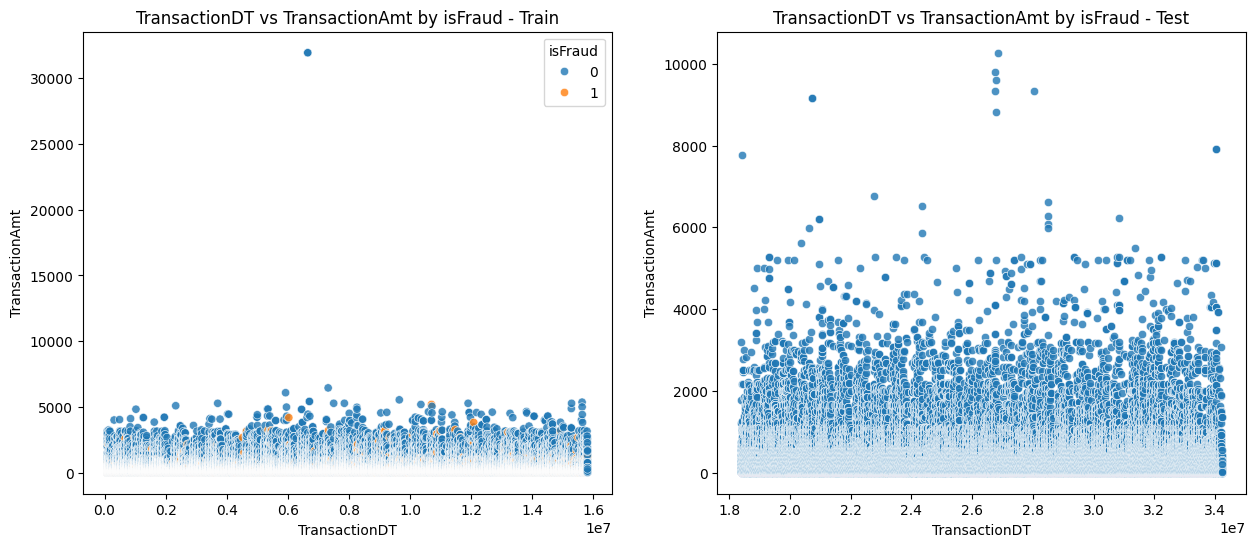

In [35]:
plt.figure(figsize = (15,6))
plt.subplot(1,2,1)
g1 = sns.scatterplot(x = "TransactionDT", y = "TransactionAmt", hue = "isFraud", data = train, alpha = 0.8, hue_order = [0,1])

plt.title('TransactionDT vs TransactionAmt by isFraud - Train')
plt.subplot(1,2,2)
sns.scatterplot(x = "TransactionDT",y="TransactionAmt", data=test, alpha=0.8, hue_order = [0,1])

plt.title('TransactionDT vs TransactionAmt by isFraud - Test')
plt.show()

In [36]:
# Remove 2 TransactionAmt Outliers.
train = train[train['TransactionAmt'] < 30000]

In [38]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,day,hour,hour_alertFeature
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,noalert
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmai

In [39]:
train.tail()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,day,hour,hour_alertFeature
590535,3577535,0,15811047,49.000000,W,6550,NaN,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN,NaN,NaN,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,3.0,2.0,29.0,29.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,56.0,56.0,NaN,NaN,NaN,56.0,T,T,T,M0,T,F,F,F,T,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,47.950001,0.000000,0.0,47.950001,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,47.950001,0.000000,0.0,47.950001,0.0,0.0,47.950001,47.950001,47.950001,0.0,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,24,mediumale

In [40]:
c_cols = [f'C{i}' for i in range(1, 15) if f'C{i}' in train.columns]

c_nan_stats = (train[c_cols].isna().mean() * 100).reset_index()
c_nan_stats.columns = ['Feature', 'NaN_Percentage']

c_nan_stats = c_nan_stats.sort_values(by='NaN_Percentage', ascending=False)

print("C Features Missing Values Analysis:")
display(c_nan_stats)

C Features Missing Values Analysis:


,Feature,NaN_Percentage
0,C1,0.0
1,C2,0.0
2,C3,0.0
3,C4,0.0
4,C5,0.0
5,C6,0.0
6,C7,0.0
7,C8,0.0
8,C9,0.0
9,C10,0.0


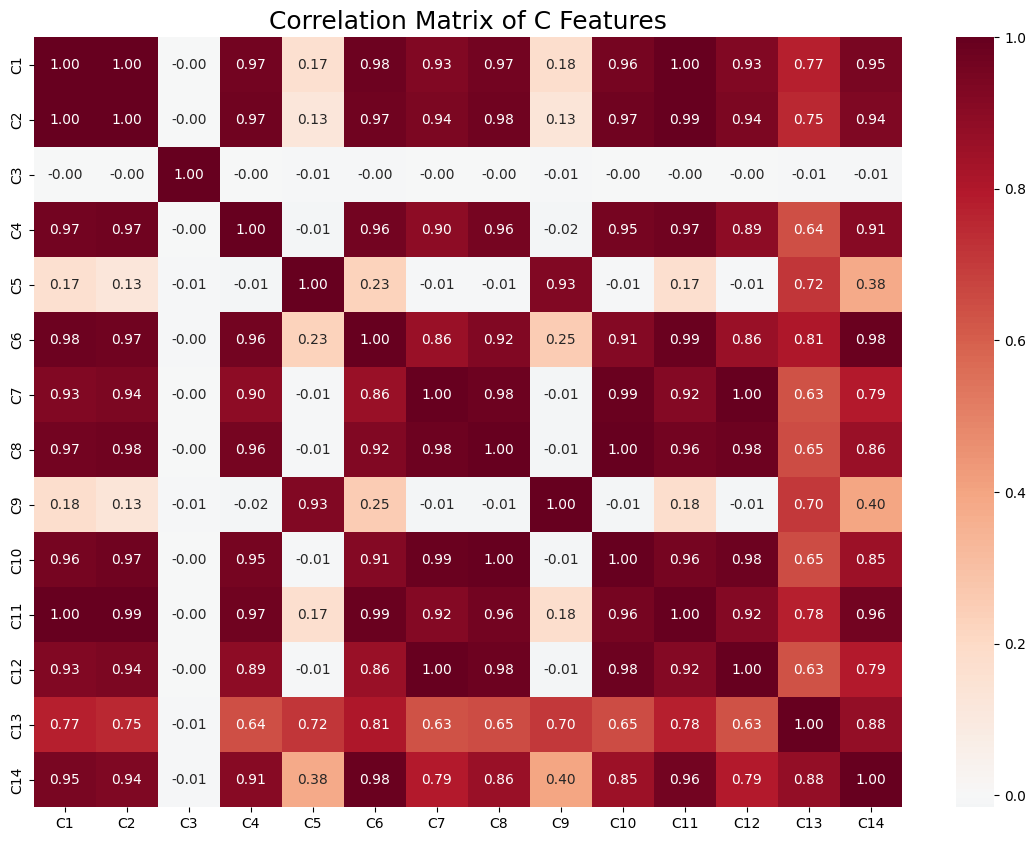

In [41]:
cor_c = train[c_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(cor_c, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Correlation Matrix of C Features', fontsize=18)
plt.show()

In [42]:
upper_c = cor_c.abs().where(np.triu(np.ones(cor_c.shape), k=1).astype(bool))

# Corr > 0.95 Threshold
to_drop_c = [column for column in upper_c.columns if any(upper_c[column] > 0.95)]


train.drop(columns=to_drop_c, inplace=True)
test.drop(columns=to_drop_c, inplace=True)

print(f"Deleted C Features: {to_drop_c}")

Deleted C Features: ['C2', 'C4', 'C6', 'C8', 'C10', 'C11', 'C12', 'C14']


In [43]:
d_cols = [f'D{i}' for i in range(1, 16) if f'D{i}' in train.columns]

d_nan_stats = (train[d_cols].isna().mean() * 100).reset_index()
d_nan_stats.columns = ['Feature', 'NaN_Percentage']

# Correlation with target
d_correlations = train[d_cols + ['isFraud']].corr()['isFraud'].reset_index()
d_correlations.columns = ['Feature', 'Correlation']

d_summary = pd.merge(d_nan_stats, d_correlations, on='Feature').sort_values(by='NaN_Percentage', ascending=False)

print("D Features: Missing Values & Correlation Analysis")
display(d_summary)

D Features: Missing Values & Correlation Analysis


,Feature,NaN_Percentage,Correlation
6,D7,93.409908,-0.127199
12,D13,89.509227,-0.059430
13,D14,89.469433,-0.008663
11,D12,89.041010,-0.028864
5,D6,87.606725,-0.057236
7,D8,87.312247,-0.142636
8,D9,87.312247,-0.044253
4,D5,52.467580,-0.064638
1,D2,47.549015,-0.083583
10,D11,47.293654,-0.045095


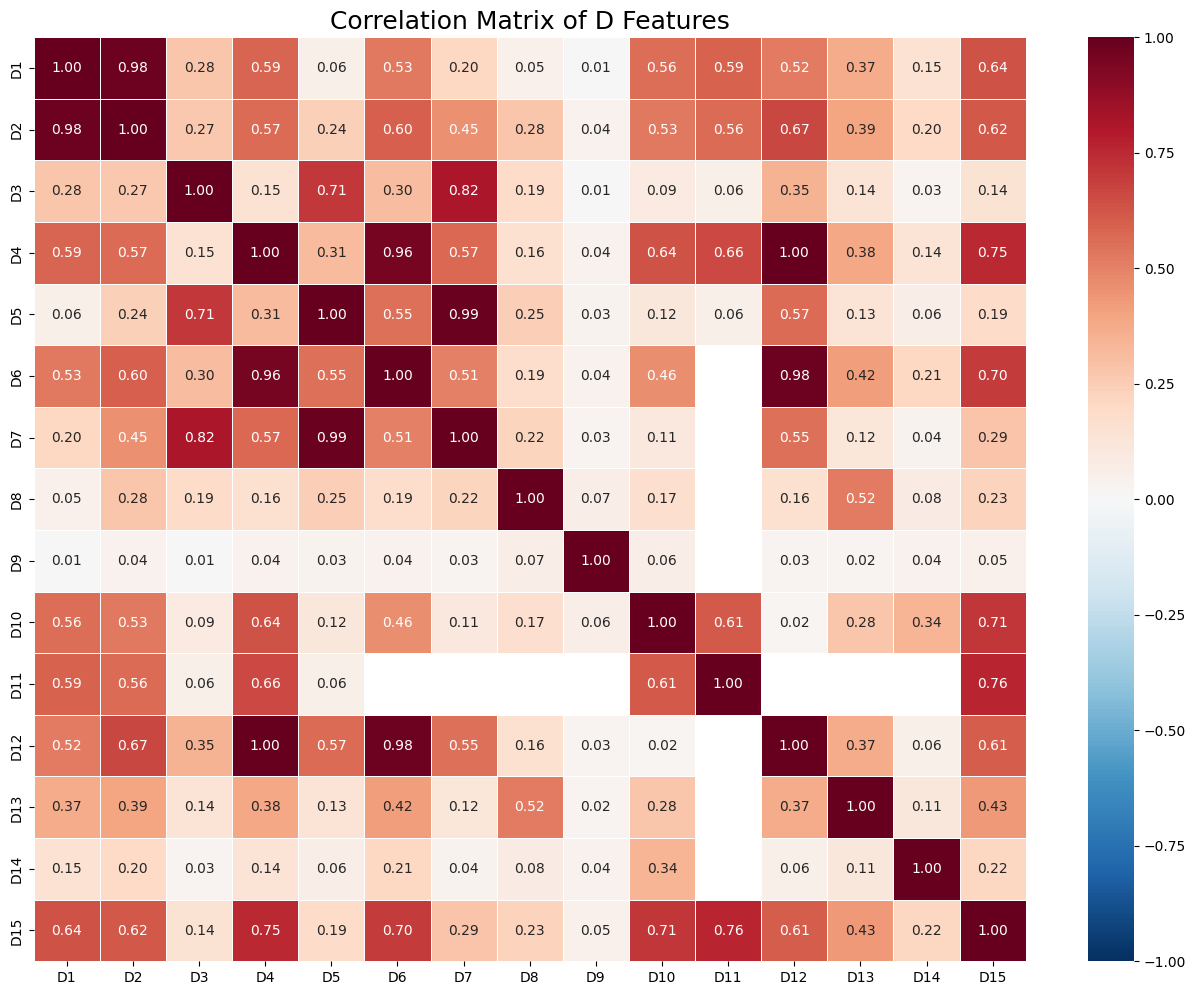

In [44]:
import seaborn as sns

cor = train[d_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(cor, 
            annot=True,         
            fmt=".2f",           
            cmap='RdBu_r',       
            vmin=-1, vmax=1,   
            center=0,
            linewidths=0.5,      
            linecolor='white')  

plt.title('Correlation Matrix of D Features', fontsize=18)
plt.show()

In [45]:
upper = cor.abs().where(np.triu(np.ones(cor.shape), k=1).astype(bool))

# Corr > 0.95 threshold
to_drop_d = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Deleted D Features: {to_drop_d}")

train.drop(columns=to_drop_d, inplace=True)
test.drop(columns=to_drop_d, inplace=True)

Deleted D Features: ['D2', 'D6', 'D7', 'D12']


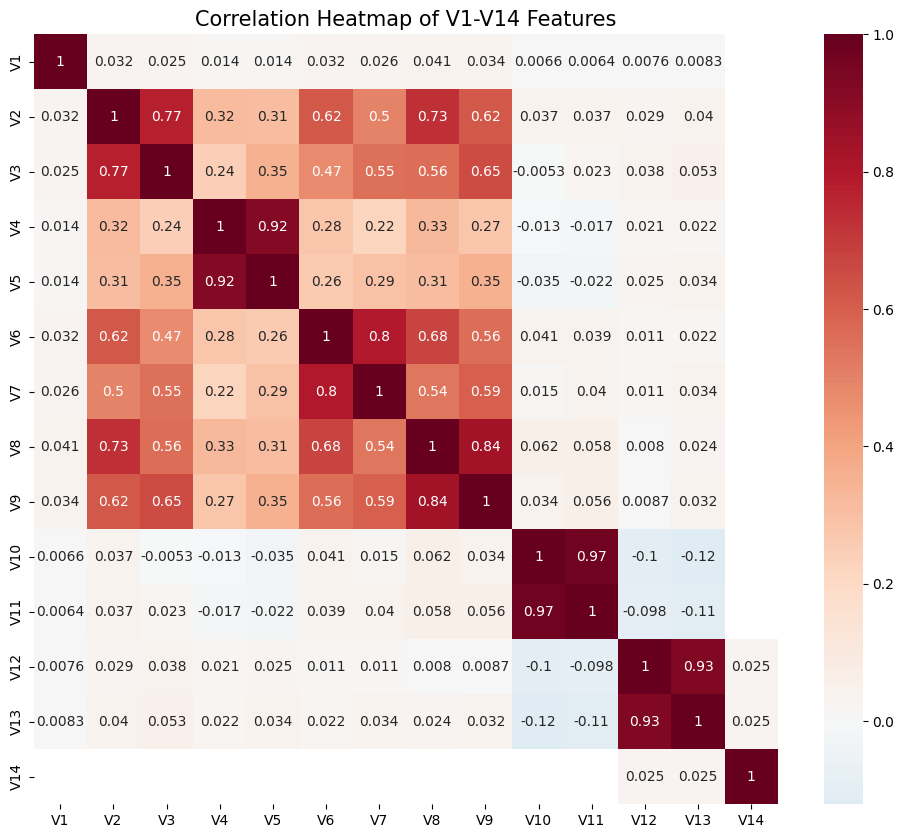

In [46]:
v_cols = [f'V{i}' for i in range(1, 15)]
plt.figure(figsize=(12, 10))
sns.heatmap(train[v_cols].corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of V1-V14 Features', fontsize=15)
plt.show()

In [47]:
# Removing useless V columns with LGBM

from lightgbm import LGBMClassifier
import pandas as pd

v_features = [c for c in train.columns if c.startswith('V')]

split_idx = int(train.shape[0] * 0.70)

X_v_train = train[v_features].iloc[:split_idx]
y_v_train = train['isFraud'].iloc[:split_idx]
X_v_val = train[v_features].iloc[split_idx:]
y_v_val = train['isFraud'].iloc[split_idx:]

clf = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1 
)

clf.fit(X_v_train, y_v_train)

v_importance = pd.DataFrame({
    'feature': v_features,
    'importance': clf.feature_importances_
})

v_to_remove = v_importance[v_importance['importance'] < 3]['feature'].tolist()

print(f"Total number of V columns: {len(v_features)}")
print(f"V columns to delete: {len(v_to_remove)}")
print(f"Needed V columns: {len(v_features) - len(v_to_remove)}")

train.drop(columns=v_to_remove, inplace=True)
test.drop(columns=v_to_remove, inplace=True)


[LightGBM] [Info] Number of positive: 14538, number of negative: 398838
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.573534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23391
[LightGBM] [Info] Number of data points in the train set: 413376, number of used features: 337
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035169 -> initscore=-3.311789
[LightGBM] [Info] Start training from score -3.311789
Total number of V columns: 339
V columns to delete: 119
Needed V columns: 220


In [48]:
# To catch sudden big amount transaction from a card

train['card1_amt_mean'] = train.groupby('card1')['TransactionAmt'].transform('mean')
test['card1_amt_mean'] = test.groupby('card1')['TransactionAmt'].transform('mean')

# Ratio of transaction
train['TransactionAmt_to_mean_card1'] = train['TransactionAmt'] / train['card1_amt_mean']
test['TransactionAmt_to_mean_card1'] = test['TransactionAmt'] / test['card1_amt_mean']

train.drop('card1_amt_mean', axis=1, inplace=True)
test.drop('card1_amt_mean', axis=1, inplace=True)

print("New Feature 'TransactionAmt_to_mean_card1'")

/tmp/ipykernel_57/1131776515.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['card1_amt_mean'] = train.groupby('card1')['TransactionAmt'].transform('mean')
/tmp/ipykernel_57/1131776515.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['card1_amt_mean'] = test.groupby('card1')['TransactionAmt'].transform('mean')
/tmp/ipykernel_57/1131776515.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

New Feature 'TransactionAmt_to_mean_card1'


In [49]:
id_cols = [c for c in train.columns if c.startswith('id_')]

id_na_stats = train[id_cols].isna().mean()

print(id_na_stats)

id_01    0.755760
id_02    0.761451
id_03    0.887689
id_04    0.887689
id_05    0.768237
id_06    0.768237
id_07    0.991271
id_08    0.991271
id_09    0.873122
id_10    0.873122
id_11    0.761272
id_12    0.755760
id_13    0.784400
id_14    0.864456
id_15    0.761260
id_16    0.780979
id_17    0.763997
id_18    0.923607
id_19    0.764083
id_20    0.764179
id_21    0.991264
id_22    0.991247
id_23    0.991247
id_24    0.991962
id_25    0.991310
id_26    0.991257
id_27    0.991247
id_28    0.761272
id_29    0.761272
id_30    0.868654
id_31    0.762451
id_32    0.868618
id_33    0.875895
id_34    0.868247
id_35    0.761260
id_36    0.761260
id_37    0.761260
id_38    0.761260
dtype: float64


In [50]:
train.isin([np.inf, -np.inf]).sum().any()

np.False_

In [51]:
# Frequency Encoding 

freq_cols = ['card1', 'card2', 'card3', 'card5', 
             'addr1', 'addr2', 
             'P_emaildomain', 'R_emaildomain']

for col in freq_cols:
    if col in train.columns:
        # Count frequencies from TRAIN only
        mapping = train[col].astype('object').value_counts(dropna=False)
        
        train[col + '_freq'] = train[col].astype('object').map(mapping).astype('int32')
        
        test[col + '_freq'] = test[col].astype('object').map(mapping).fillna(0).astype('int32')
        
        print(f"Frequency encoding finished: {col}")

train = train.copy()
test = test.copy()

/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col + '_freq'] = train[col].astype('object').map(mapping).astype('int32')
/tmp/ipykernel_57/282815845.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[col + '_freq'] = test[col].astype('object').map(mapping).fillna(0).astype('int32')
/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

Frequency encoding finished: card1
Frequency encoding finished: card2


/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col + '_freq'] = train[col].astype('object').map(mapping).astype('int32')
/tmp/ipykernel_57/282815845.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[col + '_freq'] = test[col].astype('object').map(mapping).fillna(0).astype('int32')
/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

Frequency encoding finished: card3
Frequency encoding finished: card5


/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col + '_freq'] = train[col].astype('object').map(mapping).astype('int32')
/tmp/ipykernel_57/282815845.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[col + '_freq'] = test[col].astype('object').map(mapping).fillna(0).astype('int32')
/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

Frequency encoding finished: addr1
Frequency encoding finished: addr2


/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col + '_freq'] = train[col].astype('object').map(mapping).astype('int32')
/tmp/ipykernel_57/282815845.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[col + '_freq'] = test[col].astype('object').map(mapping).fillna(0).astype('int32')
/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

Frequency encoding finished: P_emaildomain
Frequency encoding finished: R_emaildomain


In [52]:
# WOE & IV Implementation
# Applied to high amount of variable categorical columns

woe_cols = ['P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33', 'DeviceInfo']

def calculate_woe_iv(df, feature, target):
    """Calculate WOE and IV for a categorical feature."""
    df = df.copy()
    df[feature] = df[feature].astype(str).fillna('Missing')
    
    total_events = df[target].sum()        # total fraud cases
    total_non_events = (df[target] == 0).sum()  # total normal cases
    
    grouped = df.groupby(feature)[target].agg(['sum', 'count'])
    grouped.columns = ['events', 'total']
    grouped['non_events'] = grouped['total'] - grouped['events']
    
    grouped['dist_events'] = grouped['events'] / total_events
    grouped['dist_non_events'] = grouped['non_events'] / total_non_events
    
    # Avoid log(0) by clipping
    grouped['dist_events'] = grouped['dist_events'].clip(lower=1e-10)
    grouped['dist_non_events'] = grouped['dist_non_events'].clip(lower=1e-10)
    
    grouped['WOE'] = np.log(grouped['dist_events'] / grouped['dist_non_events'])
    grouped['IV'] = (grouped['dist_events'] - grouped['dist_non_events']) * grouped['WOE']
    
    iv = grouped['IV'].sum()
    return grouped['WOE'].to_dict(), iv

# Calculate WOE & IV and apply encoding
iv_summary = {}

for col in woe_cols:
    if col in train.columns:
        woe_map, iv = calculate_woe_iv(train, col, 'isFraud')
        iv_summary[col] = iv
        
        # Apply WOE encoding - train
        train[col + '_WOE'] = train[col].astype(str).fillna('Missing').map(woe_map).fillna(0)
        
        # Apply WOE encoding - test (unseen categories get 0)
        test[col + '_WOE'] = test[col].astype(str).fillna('Missing').map(woe_map).fillna(0)
        
        # Drop original column - replaced by WOE encoded version
        train.drop(columns=[col], inplace=True)
        test.drop(columns=[col], inplace=True)
        
        print(f"✅ {col} → IV: {iv:.4f} → WOE encoded")

print("\n📊 IV Summary (Feature Importance):")
print("-" * 35)
iv_df = pd.DataFrame.from_dict(iv_summary, orient='index', columns=['IV'])
iv_df = iv_df.sort_values('IV', ascending=False)
for col, row in iv_df.iterrows():
    iv = row['IV']
    if iv < 0.02:
        strength = "🔴 Useless"
    elif iv < 0.1:
        strength = "🟡 Weak"
    elif iv < 0.3:
        strength = "🟠 Medium"
    elif iv < 0.5:
        strength = "🟢 Strong"
    else:
        strength = "⚠️ Suspicious"
    print(f"{col}: {iv:.4f} → {strength}")

train = train.copy()
test = test.copy()

✅ P_emaildomain → IV: 0.2268 → WOE encoded
✅ R_emaildomain → IV: 0.6910 → WOE encoded
✅ id_30 → IV: 0.0899 → WOE encoded
✅ id_31 → IV: 0.6106 → WOE encoded
✅ id_33 → IV: 0.1626 → WOE encoded
✅ DeviceInfo → IV: 0.9754 → WOE encoded

📊 IV Summary (Feature Importance):
-----------------------------------
DeviceInfo: 0.9754 → ⚠️ Suspicious
R_emaildomain: 0.6910 → ⚠️ Suspicious
id_31: 0.6106 → ⚠️ Suspicious
P_emaildomain: 0.2268 → 🟠 Medium
id_33: 0.1626 → 🟠 Medium
id_30: 0.0899 → 🟡 Weak


In [53]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,C1,C3,C5,C7,C9,C13,D1,D3,D4,D5,D8,D9,D10,D11,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V2,V3,V4,V5,V6,V7,V12,V13,V17,V19,V20,V23,V24,V25,V26,V30,V33,V34,V35,V36,V37,V38,V39,V40,V43,V44,V45,V47,V48,V49,V51,V52,V53,V54,V55,V56,V58,V59,V60,V61,V62,V63,V64,V66,V67,V69,V70,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V85,V86,V87,V90,V91,V94,V95,V96,V99,V102,V103,V105,V108,V109,V112,V115,V124,V125,V126,V127,V128,V129,V130,V131,V133,V134,V136,V138,V139,V140,V143,V145,V146,V147,V149,V150,V151,V152,V156,V158,V159,V160,V161,V162,V164,V165,V169,V170,V171,V172,V174,V178,V180,V181,V184,V187,V188,V189,V198,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V212,V213,V214,V215,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V229,V232,V233,V234,V237,V238,V245,V251,V254,V256,V257,V258,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V285,V286,V287,V288,V289,V291,V292,V293,V294,V295,V296,V298,V300,V301,V303,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V326,V329,V331,V332,V333,V334,V335,V336,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_32,id_34,id_35,id_36,id_37,id_38,DeviceType,day,hour,hour_alertFeature,TransactionAmt_to_mean_card1,card1_freq,card2_freq,card3_freq,card5_freq,addr1_freq,addr2_freq,P_emaildomain_freq,R_emaildomain_freq,P_emaildomain_WOE,R_emaildomain_WOE,id_30_WOE,id_31_WOE,id_33_WOE,DeviceInfo_WOE
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,1.0,0.0,0.0,0.0,1.0,1.0,14.0,13.0,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,noalert,0.194640,43,8933,521285,277,23078,520479,94456,453247,-0.175038,-0.533794,-0.042874,-0.520988,-0.046727,-0.324192
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,1.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [54]:
object_cols = train.select_dtypes(include='object').columns
for col in object_cols:
    print(f"{col}: {train[col].nunique()} unique values")

ProductCD: 5 unique values
card4: 4 unique values
card6: 4 unique values
M1: 2 unique values
M2: 2 unique values
M3: 2 unique values
M4: 3 unique values
M5: 2 unique values
M6: 2 unique values
M7: 2 unique values
M8: 2 unique values
M9: 2 unique values
id_12: 2 unique values
id_15: 3 unique values
id_16: 2 unique values
id_23: 3 unique values
id_27: 2 unique values
id_28: 2 unique values
id_29: 2 unique values
id_34: 4 unique values
id_35: 2 unique values
id_36: 2 unique values
id_37: 2 unique values
id_38: 2 unique values
DeviceType: 2 unique values
hour_alertFeature: 4 unique values


In [55]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

object_cols = train.select_dtypes(include='object').columns

ohe_cols = [col for col in object_cols if train[col].nunique() <= 5]
le_cols = [col for col in object_cols if train[col].nunique() > 5]

print(f"OHE columns ({len(ohe_cols)}): {ohe_cols}")
print(" ")
print(f"LabelEncoder columns ({len(le_cols)}): {le_cols}")

# Apply OHE
print(f"\nBefore OHE - Train shape: {train.shape}")
train = pd.get_dummies(train, columns=ohe_cols)
test = test.reindex(columns=train.columns, fill_value=0)
print(f"After OHE - Train shape: {train.shape}")
print(" ")

# Apply Label Encoding
for col in le_cols:
    if col in train.columns:
        le = LabelEncoder()
        le.fit(pd.concat([train[col], test[col]]).astype(str))
        train[col] = le.transform(train[col].astype(str))
        test[col] = le.transform(test[col].astype(str))
        print(f"Label encoded: {col}")

print("✅ Encoding complete!")

OHE columns (26): ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'hour_alertFeature']
 
LabelEncoder columns (0): []

Before OHE - Train shape: (590538, 315)
After OHE - Train shape: (590538, 355)
 
✅ Encoding complete!


In [56]:
y = train['isFraud']
X = train.drop(columns=['isFraud', 'TransactionID'])

results_df = pd.DataFrame(columns=['Run Name', 'Estimators', 'Max Depth', 'Learning Rate', 'AUC Score', 'Notes'])

In [57]:
# Fill NaN

# Split
train_idx = int(len(X) * 0.70)
val_idx = int(len(X) * 0.85)

X_train, y_train = X.iloc[:train_idx].copy(), y.iloc[:train_idx].copy()
X_val, y_val = X.iloc[train_idx:val_idx].copy(), y.iloc[train_idx:val_idx].copy()
X_local_test, y_local_test = X.iloc[val_idx:].copy(), y.iloc[val_idx:].copy()

for col in X.columns:
    if X_train[col].dtype in ['int32', 'float32', 'float64']:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_val[col] = X_val[col].fillna(median_val)
        X_local_test[col] = X_local_test[col].fillna(median_val)

print("✅ Split and NaN filling complete!")

✅ Split and NaN filling complete!


# Models

In [58]:
!pip install imbalanced-learn -q
!pip install shap -q

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import mlflow
import mlflow.sklearn
import gc

RUN_RF = True  

if RUN_RF:
    
    rf_params = {
        'n_estimators': 500,
        'max_depth': 12,          
        'min_samples_split': 50,   
        'min_samples_leaf': 50,    
        'max_features': 'sqrt',
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }

    with mlflow.start_run(run_name="RandomForest_BestModel"):
        mlflow.log_params(rf_params)

        model_rf = RandomForestClassifier(**rf_params)
        model_rf.fit(X_train, y_train)

        train_probs = model_rf.predict_proba(X_train)[:, 1]
        val_probs = model_rf.predict_proba(X_val)[:, 1]
        test_probs = model_rf.predict_proba(X_local_test)[:, 1]

        test_preds = model_rf.predict(X_local_test)

        train_auc = roc_auc_score(y_train, train_probs)
        val_auc = roc_auc_score(y_val, val_probs)
        test_auc = roc_auc_score(y_local_test, test_probs)

        test_precision = precision_score(y_local_test, test_preds)
        test_recall = recall_score(y_local_test, test_preds)
        test_f1 = f1_score(y_local_test, test_preds)

        mlflow.log_metric("Train_AUC", train_auc)
        mlflow.log_metric("Validation_AUC", val_auc)
        mlflow.log_metric("Test_AUC", test_auc)
        mlflow.log_metric("Precision", test_precision)
        mlflow.log_metric("Recall", test_recall)
        mlflow.log_metric("F1", test_f1)

        print("\n" + "="*40)
        print("🎯 Final Results !!!")
        print("="*40)
        print(f"📊 Train AUC: {train_auc:.5f}")
        print(f"📊 Validation AUC: {val_auc:.5f}")
        print(f"📊 Local Test AUC: {test_auc:.5f}")
        print("-" * 40)
        print(f"🔍 Test Precision: {test_precision:.5f}")
        print(f"🎣 Test Recall: {test_recall:.5f}")
        print(f"⚖️ Test F1-Score: {test_f1:.5f}")
        print("="*40)

        mlflow.sklearn.log_model(model_rf, "rf_baseline_model")

    gc.collect()
else:
    print("⏭️ Random Forest Skipped !")

2026/05/04 12:38:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



🎯 Final Results !!!
📊 Train AUC: 0.88019
📊 Validation AUC: 0.85676
📊 Local Test AUC: 0.86235
----------------------------------------
🔍 Test Precision: 0.13851
🎣 Test Recall: 0.73078
⚖️ Test F1-Score: 0.23288


2026/05/04 12:38:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest_LessComplexity at: https://dagshub.com/Sula1909/ML-Assignment2.mlflow/#/experiments/1/runs/a4e97fc7fb484bb19571253835066b1f
🧪 View experiment at: https://dagshub.com/Sula1909/ML-Assignment2.mlflow/#/experiments/1


Shape after fix: (500, 353)
✅ SHAP values calculated!
Shape: (500, 353)


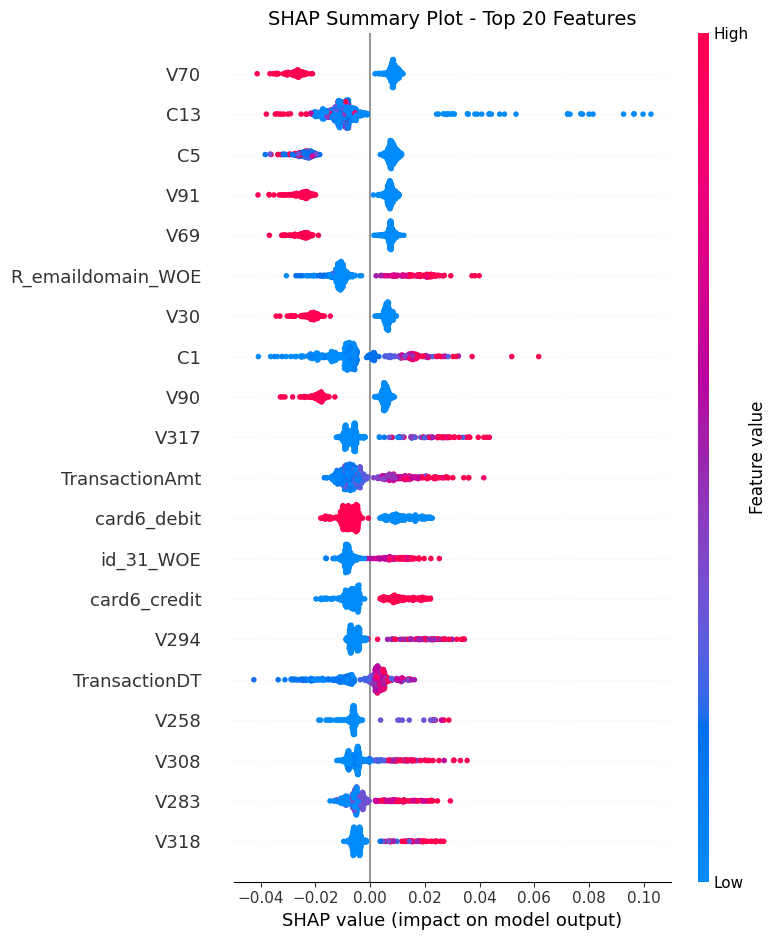

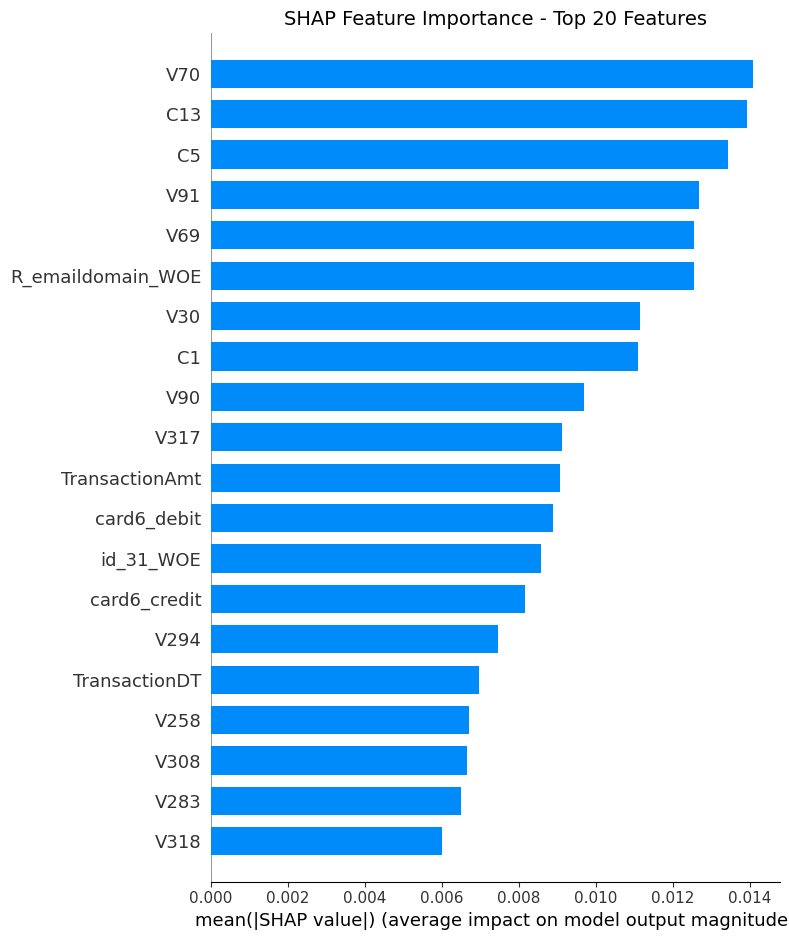

✅ SHAP plots logged to MLflow!
🏃 View run RandomForest_SHAP_Analysis at: https://dagshub.com/Sula1909/ML-Assignment2.mlflow/#/experiments/1/runs/bcf4b60bf16a4722a038bdbc041de08f
🧪 View experiment at: https://dagshub.com/Sula1909/ML-Assignment2.mlflow/#/experiments/1


In [61]:
import shap
import matplotlib.pyplot as plt

X_shap_sample = X_train.sample(500, random_state=42)

# Calculate SHAP values
explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_shap_sample)

# For RandomForest binary classification, shap_values is a list of 2 arrays
# Index [1] = fraud class (what we care about)

if isinstance(shap_values, list):
    shap_values_fraud = shap_values[1]  # old SHAP format
else:
    shap_values_fraud = shap_values[:, :, 1]  # new SHAP format

print(f"Shape after fix: {shap_values_fraud.shape}")

print("✅ SHAP values calculated!")
print(f"Shape: {shap_values_fraud.shape}")

# Plot 1 - Summary Plot (shows direction and magnitude)
plt.figure()
shap.summary_plot(shap_values_fraud, X_shap_sample, max_display=20, show=False)
plt.title("SHAP Summary Plot - Top 20 Features", fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 - Bar Plot (simple importance ranking)
plt.figure()
shap.summary_plot(shap_values_fraud, X_shap_sample, plot_type="bar", max_display=20, show=False)
plt.title("SHAP Feature Importance - Top 20 Features", fontsize=14)
plt.tight_layout()
plt.savefig("shap_bar_plot.png", dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name="RandomForest_SHAP_Analysis"):
    mlflow.log_artifact("shap_summary_plot.png")
    mlflow.log_artifact("shap_bar_plot.png")
    print("✅ SHAP plots logged to MLflow!")

In [ ]:
run_balanced = False

if run_balanced:
    from imblearn.ensemble import BalancedRandomForestClassifier
    from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
    import mlflow
    import mlflow.sklearn
    import gc


    brf_params = {
        'n_estimators': 500,
        'max_depth': 15,
        'min_samples_split': 20,
        'min_samples_leaf': 20,
        'max_features': 'sqrt',
        'bootstrap': False,
        'random_state': 42,
        'n_jobs': -1
    }

    with mlflow.start_run(run_name="BalancedRandomForest_Tuned"):
        mlflow.log_params(brf_params)

        model_brf = BalancedRandomForestClassifier(**brf_params)
        model_brf.fit(X_train, y_train)

        train_probs = model_brf.predict_proba(X_train)[:, 1]
        val_probs = model_brf.predict_proba(X_val)[:, 1]
        test_probs = model_brf.predict_proba(X_local_test)[:, 1]

        test_preds = model_brf.predict(X_local_test)

        train_auc = roc_auc_score(y_train, train_probs)
        val_auc = roc_auc_score(y_val, val_probs)
        test_auc = roc_auc_score(y_local_test, test_probs)

        test_precision = precision_score(y_local_test, test_preds)
        test_recall = recall_score(y_local_test, test_preds)
        test_f1 = f1_score(y_local_test, test_preds)

        mlflow.log_metric("Train_AUC", train_auc)
        mlflow.log_metric("Validation_AUC", val_auc)
        mlflow.log_metric("Test_AUC", test_auc)
        mlflow.log_metric("Precision", test_precision)
        mlflow.log_metric("Recall", test_recall)
        mlflow.log_metric("F1", test_f1)

        print("\n" + "="*40)
        print("🎯 Final Results !!!")
        print("="*40)
        print(f"📊 Train AUC: {train_auc:.5f}")
        print(f"📊 Validation AUC: {val_auc:.5f}")
        print(f"📊 Local Test AUC: {test_auc:.5f}")
        print("-" * 40)
        print(f"🔍 Test Precision: {test_precision:.5f}")
        print(f"🎣 Test Recall: {test_recall:.5f}")
        print(f"⚖️ Test F1-Score: {test_f1:.5f}")
        print("="*40)

        mlflow.sklearn.log_model(model_brf, "brf_baseline_model")

    del model_brf
    gc.collect()